*** This Code is for Extracting ship information from NovaSAR images and their corresponding AIS data

In [1]:
# Import dependencies

import os
import numpy as np
import math
from datetime import datetime, date
import matplotlib.pyplot as plt
import rasterio as rio
import warnings
warnings.filterwarnings("ignore")

In [2]:
from functions import *

# NovaSAR images

In [3]:
head_dir = "/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/"

# data_time = "Airbus_2024Feb23"
data_time = "Airbus_2024Jan11"
# data_time = "Airbus_2024Jun13"

In [ ]:
# Directory containing the tif files:
dir_all = os.path.join(head_dir, data_time)
print(f"Processing directory: {dir_all}")



Processing directory: /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11


#### Tif images

ALL tif files in the directory

In [5]:
# Get a list of .tif files in the directory:

tif_files, grouped_tif_files = get_file_list(dir_all)

print(f"Found {len(tif_files)} tif files.")

# Example: Print grouped files
for folder, files in grouped_tif_files.items():
    print(f"Folder: {folder}")
    print(f"Files: {files}\n")
tif_files

Found 413 tif files.
Folder: NovaSAR_01_50023_grd_231122_222446_HH
Files: ['/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_50023_grd_231122_222446_HH/NovaSAR_01_50023_grd_13_231122_222446_HH_1/image_HH.tif', '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_50023_grd_231122_222446_HH/NovaSAR_01_50023_grd_13_231122_222451_HH_2/image_HH.tif', '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_50023_grd_231122_222446_HH/NovaSAR_01_50023_grd_13_231122_222457_HH_3/image_HH.tif', '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_50023_grd_231122_222446_HH/NovaSAR_01_50023_grd_13_231122_222503_HH_4/image_HH.tif', '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_50023_grd_231122_222446_HH/NovaSAR_01_50023_grd_13_231122_222508_HH_5/image_HH.tif', '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_50023_grd_231122_222446_HH/NovaSAR_01_50023_grd_13_231122_222514_HH_6/image_HH.tif', '/mnt/e

['/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_50023_grd_231122_222446_HH/NovaSAR_01_50023_grd_13_231122_222446_HH_1/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_50023_grd_231122_222446_HH/NovaSAR_01_50023_grd_13_231122_222451_HH_2/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_50023_grd_231122_222446_HH/NovaSAR_01_50023_grd_13_231122_222457_HH_3/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_50023_grd_231122_222446_HH/NovaSAR_01_50023_grd_13_231122_222503_HH_4/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_50023_grd_231122_222446_HH/NovaSAR_01_50023_grd_13_231122_222508_HH_5/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_50023_grd_231122_222446_HH/NovaSAR_01_50023_grd_13_231122_222514_HH_6/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_50023_g

Chosen tif file

In [19]:
# Choose an index of a tif file to process:
tii = 392#15#2#150#3# 

In [20]:
from pathlib import Path

# Sample image Full path
tii_path = Path(tif_files[tii][:-12])
parts = tii_path.parts

im_name = parts[-1]
print(f"Sample image (tii) name: {im_name}")
print(f"Sample image (tii) path:\n{tii_path}")

Sample image (tii) name: NovaSAR_01_51291_grd_13_240105_084141_HH_1
Sample image (tii) path:
/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_51291_grd_240105_084141_HH/NovaSAR_01_51291_grd_13_240105_084141_HH_1


Time of Acquisition

In [21]:
# Find the data acquisition date from the metadata XML file:
from datetime import datetime

# srcattr_info_elem = root.find(".//Source_Attributes")
# # Extract RawDataStartTime
# elem = srcattr_info_elem.find(".//RawDataStartTime")
# acqdate0 = elem.text if elem is not None else None
# # Change the date format from 'YYYY-MM-DD HH:MM:SS.ssssss' to 'DD/MM/YYYY HH:MM:SS'
# dt = datetime.strptime(acqdate0, '%Y-%m-%d %H:%M:%S.%f')

acqdate0 = f"20{'_'.join(parts[-1].split('_')[-4:-2])}" # or f"20{tif_files[tii][-31:-18]}" # YYYYMMDD_HHMMSS
dt = datetime.strptime(acqdate0, '%Y%m%d_%H%M%S')

acqdate = dt.strftime('%d/%m/%Y %H:%M:%S') # DD/MM/YYYY HH:MM:SS
print("Raw Data Start Time:", acqdate)

Raw Data Start Time: 05/01/2024 08:41:41


Geo and Image Information

In [22]:
parts = tii_path.parts
'/'.join(parts[:-1])

Path(*parts[:-1])

PosixPath('/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_51291_grd_240105_084141_HH')

In [23]:
# Extract Geo and Image information from the metadata XML file:
metadata_path = f"{tii_path}/metadata.xml"
geo_info = geo_info_from_metadata(metadata_path)

#### Correct Georeferencing Error

Image Initial Transformation matrix (based on metadata)

In [24]:
# Generate CRS and transform using ellipsoid and tiepoints information extracted from the metadata XML file:
from rasterio.crs import CRS

# Use ellipsoid parameters for CRS, fallback to WGS84 if not available
if geo_info['ellipsoid'] == "WGS84":
    crs = CRS.from_epsg(4326)
else:
    crs = CRS.from_string(f"+proj=longlat +a={geo_info['SemiMajorAxis_name']} +b={geo_info['SemiMinorAxis_name']} +no_defs")

transform0 = rio.transform.from_gcps(geo_info['tiepoints'])
print("Initial Georeferencing Transformation Matrix:", transform0)

Initial Georeferencing Transformation Matrix: |-0.00,-0.00, 9.20|
|-0.00, 0.00, 53.73|
| 0.00, 0.00, 1.00|


New tiepoint pairs

In [28]:
# Load the modified tie points (based on OSM and NovaSAR images) from shapefiles

# Find the index of 'NovaSAR' in the path parts
parts = tii_path.parts
# nova_index = parts.index('NovaSAR')

# nova_path = Path(*parts[:nova_index + 1])
nova_path = Path(*parts[:-1])

tie_im_path = f"{nova_path}/modified tie points/im_points.shp"
tie_osm_path = f"{nova_path}/modified tie points/osm_points.shp"
nova_path

PosixPath('/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jan11/NovaSAR_01_51291_grd_240105_084141_HH')

 Relative transformation between the image (incorrect georeferencing) and OSM (correct georeferencing)

In [26]:
delta = relative_transform_im_osm(tie_im_path, tie_osm_path)

Corrected Transformation

In [29]:
# Corrected transformation matrix
transform=delta*transform0
transform

Affine(-3.606765291754438e-05, -1.1022953737000004e-05, 9.194082990462338,
       -6.606260680281531e-06, 2.1497568784673482e-05, 53.728267831616066)

Generate a new geotif with corrected georeferencing

In [15]:
new_geotif(tif_file_path = tif_files[tii], transform = transform, crs = crs, out_file_path = f"{tii_path}/image_HH_corrected.tif")

Warning 1: TIFFFetchNormalTag:ASCII value for tag "ImageDescription" contains null byte in value; value incorrectly truncated during reading due to implementation limitations



Saved corrected image to /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53556_grd_240412_083034_HH/NovaSAR_01_53556_grd_13_240412_083045_HH_3/image_HH_corrected.tif


Warning 1: TIFFFetchNormalTag:ASCII value for tag "ImageDescription" contains null byte in value; value incorrectly truncated during reading due to implementation limitations


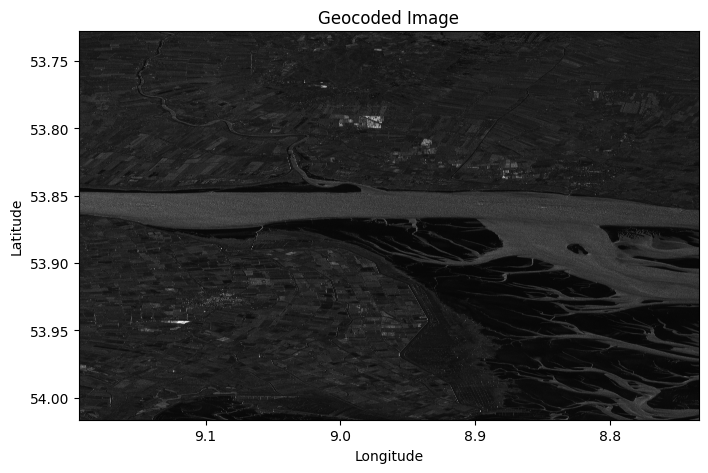

In [30]:
import rasterio.plot
src = rio.open(tif_files[tii])
im = src.read(1)
im_uint8 = (255*im/1500).astype(np.uint8)
fig, ax = plt.subplots(figsize=(8, 8))
rio.plot.show(im, ax=ax, transform=transform, cmap='gray', vmin=0, vmax=1500)
ax.set_title("Geocoded Image")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

#### AIS

In [31]:
# AIS data Path:

# ais_name = f"aisdk-{acqdate0[:10]}"  # Extract the date part (YYYY-MM-DD)       
ais_name = f"aisdk-{acqdate0[:8][:4]}-{acqdate0[:8][4:6]}-{acqdate0[:8][6:8]}"  # Extract the date part (YYYY-MM-DD)       

csv_dir = f"{head_dir}AIS_dataset/{ais_name}/{ais_name}.csv" 
# csv_dir = r"E:\AssenSAR\CSP LIDAR Data\NovaSAR\AIS_dataset\aisdk-2024-04-15\aisdk-2024-04-15.csv" 

print(f"AIS file name: {ais_name}")
print(f"AIS data CSV file path: {csv_dir}")


AIS file name: aisdk-2024-01-05
AIS data CSV file path: /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/AIS_dataset/aisdk-2024-01-05/aisdk-2024-01-05.csv


Find Lat and Lon extent in the image

In [32]:
lat_min, lon_min, lat_max, lon_max = get_geotif_LatLon_extent(f'{tii_path}/image_HH_corrected.tif')

print(f"Latitude extent: {lat_min} to {lat_max}")
print(f"Longitude extent: {lon_min} to {lon_max}")

Latitude extent: 53.67599909711368 to 54.068445360064736
Longitude extent: 8.734288500644439 to 9.194082990462338


Extract the Corresponding AIS data for the date and spatial extent of the SAR image

In [47]:
def load_AIS_df(ais_csv_dir, acqdate=None, lat_min=None, lon_min=None, lat_max=None, lon_max=None, time_buffer=[1], remove_duplicate_names=True):
    """
    Load AIS data from a CSV file and filter it based on acquisition date and spatial extent.
    
    Parameters:
    - ais_csv_dir: Path to the AIS CSV file.
    - acqdate: Acquisition date in 'DD/MM/YYYY HH:MM:SS' format.
    - lat_min, lon_min, lat_max, lon_max: Spatial extent for filtering.
    - time_buffer: List of time buffer values in seconds.
    
    Returns:
    - DataFrame containing filtered AIS data.
    """
    import pandas as pd
    from datetime import datetime, timedelta
    
    lat_col       = 'Latitude'
    lon_col       = 'Longitude'
    timestamp_col = '# Timestamp'
    
    chunks = []
    for t_bii in time_buffer:
        if acqdate != None:
            start_time = (datetime.strptime(acqdate, '%d/%m/%Y %H:%M:%S') - timedelta(seconds=t_bii)).strftime('%d/%m/%Y %H:%M:%S')
            end_time   = (datetime.strptime(acqdate, '%d/%m/%Y %H:%M:%S') + timedelta(seconds=t_bii)).strftime('%d/%m/%Y %H:%M:%S')

        for chunk in pd.read_csv(ais_csv_dir, chunksize=500000):
            if acqdate != None:
                mask = (chunk[timestamp_col] >= start_time) & (chunk[timestamp_col] <= end_time) & \
                    (chunk[lat_col] >= lat_min) & (chunk[lat_col] <= lat_max) & \
                    (chunk[lon_col] >= lon_min) & (chunk[lon_col] <= lon_max)
            else:
                mask = (chunk[lat_col] >= lat_min) & (chunk[lat_col] <= lat_max) & \
                    (chunk[lon_col] >= lon_min) & (chunk[lon_col] <= lon_max)

            filtered = chunk[mask]
            if not filtered.empty:
                chunks.append(filtered)

    if len(chunks)>0:
           AIS_df = pd.concat(chunks, ignore_index=True)  # concatenate all chunks into a single DataFrame
           if remove_duplicate_names:
               AIS_df = AIS_df.drop_duplicates(subset=["Name", "Ship type", "Width", "Length"])  # Remove duplicate entries based on Name, Ship type, Width, and Length
    else:
        print("No AIS data found within the specified time and spatial bounds.")
        AIS_df = []
    
    return AIS_df

In [48]:
time_buffer = [100,100]  # seconds
AIS_df = load_AIS_df(csv_dir, acqdate=None, lat_min=lat_min, lon_min=lon_min, lat_max=lat_max, lon_max=lon_max, time_buffer=time_buffer, remove_duplicate_names=False)

In [60]:
AIS_df[90:100]

,# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,...,Length,Type of position fixing device,Draught,Destination,ETA,Data source type,A,B,C,D
90,05/01/2024 18:15:23,Class A,244992000,53.887200,9.164083,Under way using engine,0.0,0.0,341.0,141.0,...,96.0,GPS,3.4,ELBE DREDGING OPS,18/11/2024 04:00:00,AIS,81.0,15.0,8.0,10.0
91,05/01/2024 19:36:20,Class A,244992000,53.862617,9.045950,Under way using engine,0.0,10.8,67.0,69.0,...,96.0,GPS,3.4,ELBE DREDGING OPS,18/11/2024 04:00:00,AIS,81.0,15.0,8.0,10.0
92,05/01/2024 21:40:57,Class A,246849000,53.883853,9.088143,Under way using engine,0.0,5.3,82.6,83.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
93,05/01/2024 22:21:27,Class A,247389200,53.847012,8.766047,Under way using engine,-6.4,12.2,127.5,122.0,...,337.0,Combined GPS/GLONASS,8.6,DEHAM,05/01/2024 21:00:00,AIS,33.0,304.0,29.0,29.0
94,05/01/2024 22:27:06,Class A,247389200,53.839762,8.795280,Under way using engine,-8.7,12.3,97.7,97.0,...,337.0,Combined GPS/GLONASS,8.6,DEHAM,05/01/2024 21:00:00,AIS,33.0,304.0,29.0,29.0
95,05/01/2024 22:57:59,Class A,255806248,53.880343,9.075955,Under way using engine,0.0,5.4,54.5,65.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
96,05/01/2024 22:59:47,Class A,247389200,53.849623,8.983512,Under way using engine,-5.4,12.4,75.1,76.0,...,337.0,Combined GPS/GLONASS,8.6,DEHAM,05/01/2024 21:00:00,AIS,33.0,304.0,29.0,29.0
97,05/01/2024 23:01:07,Class A,247389200,53.850822,8.991038,Under way using engine,-1.1,12.3,74.3,75.0,...,337.0,Combined GPS/GLONASS,8.6,DEHAM,05/01/2024 21:00:00,AIS,33.0,304.0,29.0,29.0
98,05/01/2024 23:01:17,Class A,247389200,53.850958,8.991873,Under way using engine,1.1,12.3,74.4,75.0,...,337.0,Combined GPS/GLONASS,8.6,DEHAM,05/01/2024 21:00:00,AIS,33.0,304.0,29.0,29.0
99,05/01/2024 23:02:46,Class A,247389200,53.852300,9.000187,Under way using engine,0.0,12.4,75.4,75.0,...,337.0,Combined GPS/GLONASS,8.6,DEHAM,05/01/2024 21:00:00,AIS,33.0,304.0,29.0,29.0


In [23]:
# Save the filtered AIS data to a CSV file:
AIS_df.to_csv(f"{tii_path}/AIS.csv", index=False)
print(f"Saved AIS data to {tii_path}/AIS.csv")

Saved AIS data to /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082446_HH_2/AIS.csv


### Extract Patches

Extract row and column indices corresponding to the AIS samples

In [57]:
row_AIS, col_AIS = AIS_row_col_from_lat_lon(lat_AIS = AIS_df['Latitude'], lon_AIS = AIS_df['Longitude'], im_path=f'{tii_path}/image_HH_corrected.tif')

Plot the image and AIS points

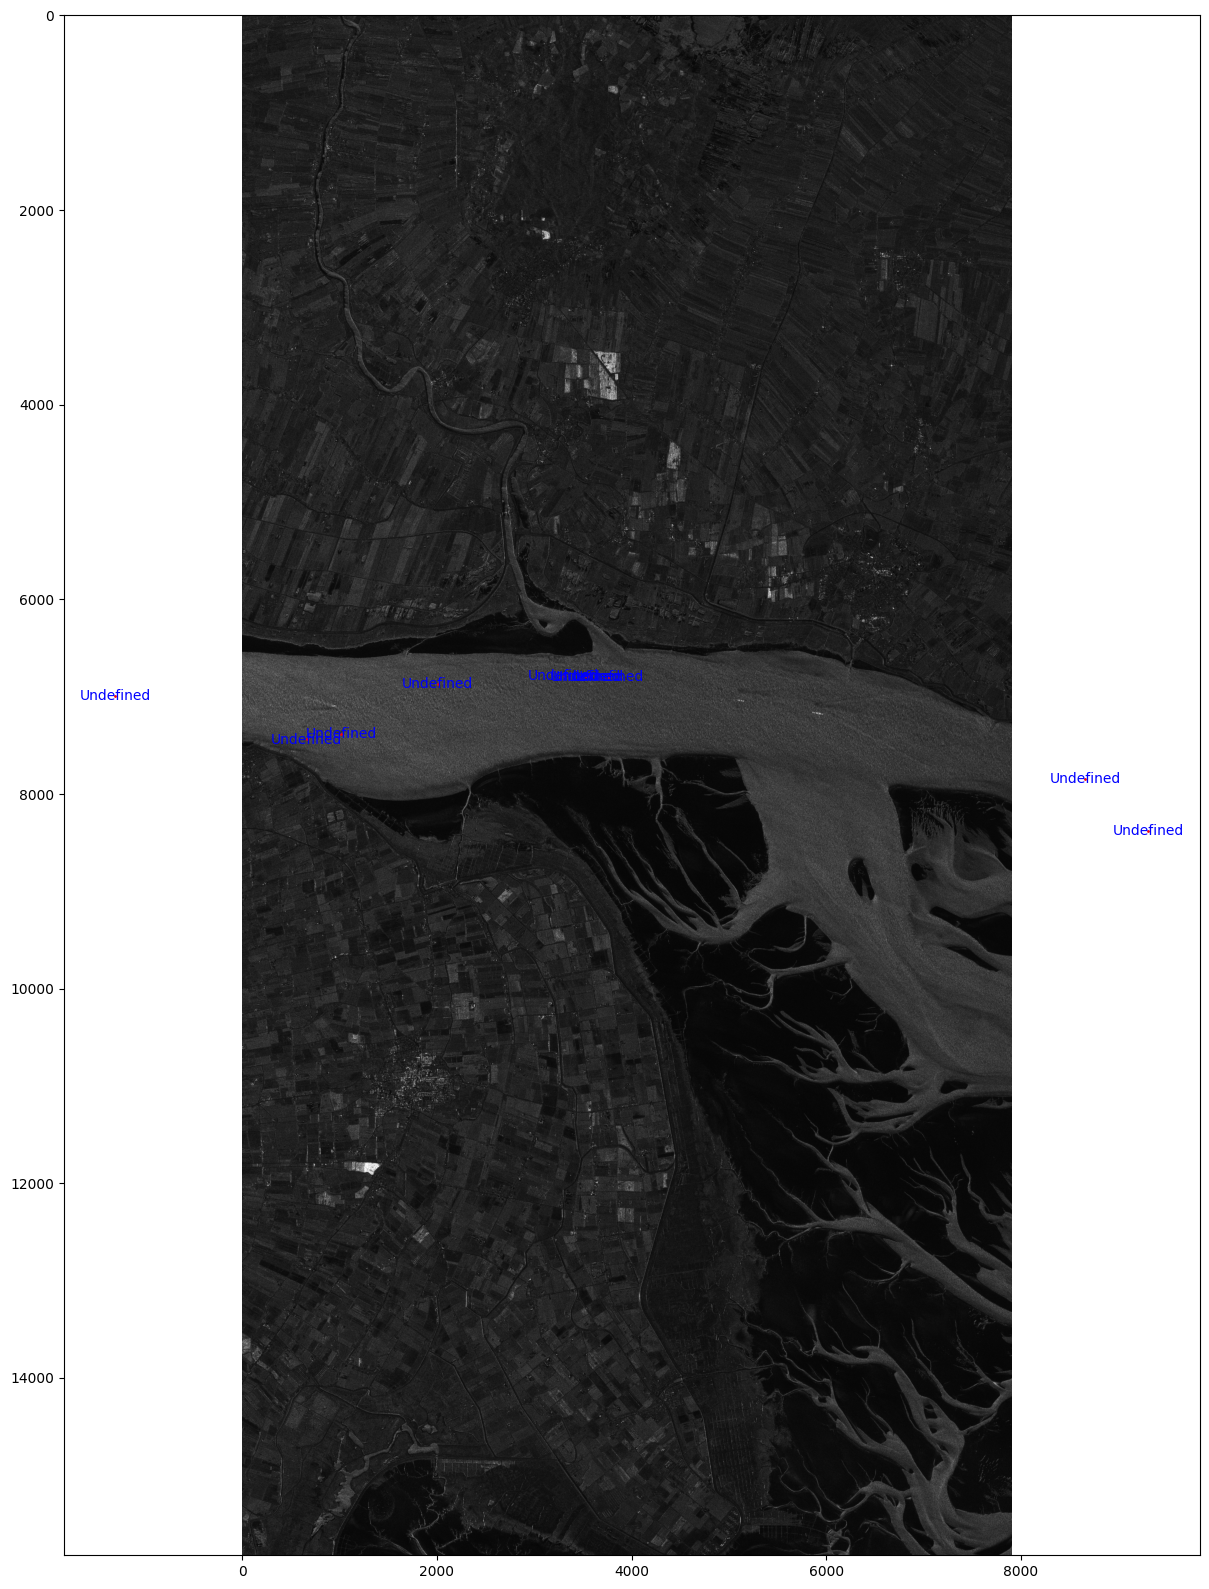

In [61]:
src = rio.open(f'{tii_path}/image_HH_corrected.tif')
plt.figure(figsize=(30, 20))
plt.imshow(src.read(1), cmap='gray', vmin=0, vmax=1500)
plt.scatter(col_AIS[90:100], row_AIS[90:100], c='red', s=1, label='AIS Points');

for r_ii, c_ii, sh_t_ii in zip(row_AIS[90:100], col_AIS[90:100], AIS_df['Ship type']):
    plt.text(c_ii, r_ii, f"{sh_t_ii}", fontsize=10, color='blue', ha='center', va='center')

In [ ]:
h= 128  # Half height for patch
w= 128  # Half width for patch

patch_output_dir = f"{tii_path}/ship_patches"
AIS_df = ship_patches(im_path=f'{tii_path}/image_HH_corrected.tif', 
                      im_name=im_name,
                      patch_output_dir=patch_output_dir, 
                      AIS_df=AIS_df, 
                      row_AIS=row_AIS, 
                      col_AIS=col_AIS, 
                      h=h, 
                      w=w,
                      uint8=True,
                      plt_ptch=False)

# Save the updated AIS data with patch names:
AIS_df.to_csv(f"{tii_path}/AIS.csv", index=False)
print(f"Saved the updataed AIS data with patch_names column to {tii_path}/AIS.csv")

Skipping patch for row 5122, col 7995 due to out of bounds.
Skipping patch for row 9749, col 8368 due to out of bounds.


### Detection

### Download Sentinel (GEE)

In [13]:
import ee
ee.Authenticate()
ee.Initialize()


In [ ]:
ii = 0 
aoi = ee.Geometry.Rectangle([AIS_df['Longitude'][ii]-0.065, AIS_df['Latitude'][ii]-0.065, AIS_df['Longitude'][ii]+0.065, AIS_df['Latitude'][ii]+0.065])

aoi = ee.Geometry.Rectangle([(lon_min+lon_max)/2-0.065, (lat_min+lat_max)/2-0.065, (lon_min+lon_max)/2+0.065, (lat_min+lat_max)/2+0.065])  # Example coordinates, replace with actual values
aoi = ee.Geometry.Rectangle([11.43, 54.55, 11.56, 54.68])  # Example coordinates, replace with actual values

In [15]:
start_date = '2024-04-09'#f"{acqdate0[:8][:4]}-{acqdate0[:8][4:6]}-{acqdate0[:8][6:8]}"  # Extract the date part (YYYY-MM-DD) 
end_date   = '2024-04-15'

In [16]:
# Load Sentinel-1 Collection
sentinel1 = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(aoi) \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filterDate(start_date, end_date) \
    # .filter(ee.Filter.eq('system:index', image_name)) \
    # .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
    # .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')) \
    # .select(['VV', 'VH'])


image_list = sentinel1.toList(sentinel1.size())

In [17]:
# Print image names
image_name = []
image_list = sentinel1.toList(sentinel1.size())
for ii in range(image_list.size().getInfo()):
    image = ee.Image(image_list.get(ii))
    image_name.append(image.get('system:index').getInfo())
    print(image_name[-1])


S1A_IW_GRDH_1SDV_20240413T165325_20240413T165350_053418_067ACC_B8F3


In [ ]:
import os

download_dir = f"{tii_path}S1"  # Change this path as needed

# Create the directory if it doesn't exist
if not os.path.exists(download_dir):
    os.makedirs(download_dir)

In [21]:
# S1 Download:

# Function to download Sentinel-1 image
# This function downloads the Sentinel-1 image and saves it as a GeoTIFF file
def download_image(image, aoi, download_dir):
    import requests
    orbit_pass = image.get('orbitProperties_pass').getInfo()

    # Generate download URL for the entire image (all bands)
    url = image.getDownloadUrl({
        'scale': 10,
        'region': aoi.getInfo()['coordinates'],
        'format': 'GEO_TIFF',
        'crs': 'EPSG:4326'
    })
    response = requests.get(url)
    
    filename = f"Sentinel1_{image.get('system:index').getInfo()}_{orbit_pass}.tif"
    filepath = os.path.join(download_dir, filename)
    
    with open(filepath, 'wb') as file:
        file.write(response.content)
    
    print(f"Downloaded: {filename} → {download_dir}")



# Loop through images and download each one (with all bands)

for ii in range(image_list.size().getInfo()):
    image = ee.Image(image_list.get(ii))
    image_name = image.get('system:index').getInfo()
    orbit_pass = image.get('orbitProperties_pass').getInfo()
    s1_filename = f"Sentinel1_{image_name}_{orbit_pass}.tif"
    s1_filepath = os.path.join(download_dir, s1_filename)
    if not os.path.exists(s1_filepath):
        print(f"Downloading: {s1_filename}")
        download_image(image, aoi, download_dir)
    else:
        print(f"File already exists: {s1_filename}")

Downloading: Sentinel1_S1A_IW_GRDH_1SDV_20240413T165325_20240413T165350_053418_067ACC_B8F3_ASCENDING.tif
Downloaded: Sentinel1_S1A_IW_GRDH_1SDV_20240413T165325_20240413T165350_053418_067ACC_B8F3_ASCENDING.tif → /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082452_HH_3/S1


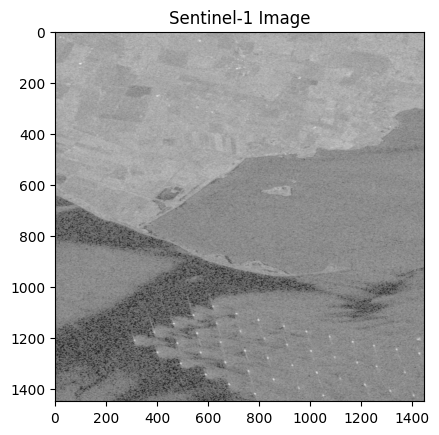

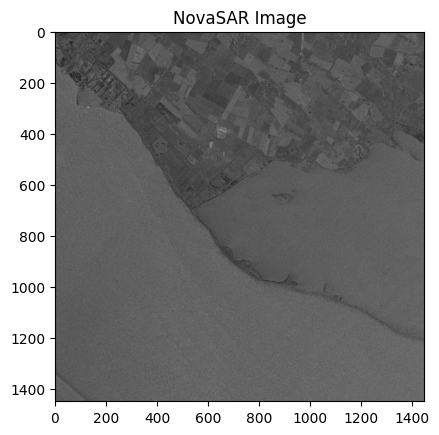

In [50]:
import cv2

s1_src = rio.open(f"{s1_filepath}")
s1_im = s1_src.read(1)
# scale_factor = 4 # Scale factors
# s1_im = cv2.resize(s1_im, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_LINEAR)
s1_im -= s1_im.min()
s1_im /= s1_im.max()  # Normalize to [0, 1]
s1_im *= 255  # Scale to [0, 255]
s1_im = s1_im.astype(np.uint8)  # Convert to uint8 for visualization
plt.figure()
plt.imshow(s1_im, cmap='gray')
plt.title(f"Sentinel-1 Image");


nova_src = s1_src = rio.open(tif_files[tii])
nova_im = np.fliplr(np.flipud(np.log10(nova_src.read(1)))) 
scale_factor = 1/4 # Scale factors
nova_im = cv2.resize(nova_im, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_LINEAR)

nova_im = nova_im[nova_im.shape[0]//2-s1_im.shape[0]//2:nova_im.shape[0]//2+s1_im.shape[0]//2, nova_im.shape[1]//2-s1_im.shape[1]//2:nova_im.shape[1]//2+s1_im.shape[1]//2]  # Crop to the lower right quadrant
nova_im -= nova_im.min()
nova_im /= nova_im.max()  # Normalize to [0, 1]
nova_im *= 255  # Scale to [0, 255]
nova_im = nova_im.astype(np.uint8)  # Convert to uint8 for visualization
plt.figure()
plt.imshow(nova_im, cmap='gray')
plt.title(f"NovaSAR Image");







### NovaSAR - S1 Matching

In [53]:
import cv2

# Initialize ORB detector
# orb = cv2.ORB_create()
sift = cv2.SIFT_create()


# Find keypoints and descriptors
# kp1, des1 = orb.detectAndCompute(nova_im, None)
# kp2, des2 = orb.detectAndCompute(s1_im, None)

kp1, des1 = sift.detectAndCompute(nova_im[:3500,:], None)
kp2, des2 = sift.detectAndCompute(s1_im[:3500,:], None)

# Match descriptors using Brute-Force matcher
# bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
bf = cv2.BFMatcher(cv2.NORM_L1, crossCheck=True)

matches = bf.match(des1, des2)

# Sort matches by distance (best matches first)
matches = sorted(matches, key=lambda x: x.distance)

# Take the top 90 % matches forward.
matches = matches[:int(len(matches)*0.1)]
no_of_matches = len(matches)

# Define empty matrices of shape no_of_matches * 2.
p_nova = np.zeros((no_of_matches, 2))
p_s1 = np.zeros((no_of_matches, 2))
for ii in range(len(matches)):
  p_nova[ii, :] = kp1[matches[ii].queryIdx].pt
  p_s1[ii, :] = kp2[matches[ii].trainIdx].pt

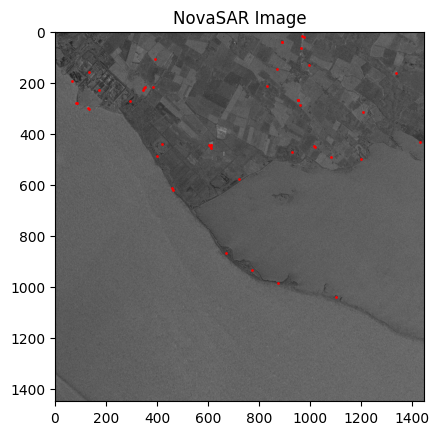

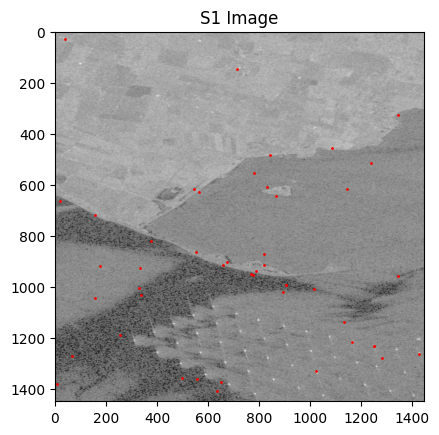

In [54]:
plt.figure()
plt.imshow(nova_im, cmap='gray')
plt.scatter(p_nova[:, 0], p_nova[:, 1], c='r', s=1, label='NovaSAR Keypoints')
plt.title(f"NovaSAR Image");

plt.figure()
plt.imshow(s1_im, cmap='gray')
plt.scatter(p_s1[:, 0], p_s1[:, 1], c='r', s=1, label='S1 Keypoints')
plt.title(f"S1 Image");